## Random Forest Evaluations

c:\Users\hasit\OneDrive\Documents\Projects\HealthIntel\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading preprocessed data...
Loading trained models...

--- Classification Report (Calibrated Model) ---
              precision    recall  f1-score   support

 No Diabetes       0.79      0.72      0.75     35026
    Diabetes       0.74      0.81      0.77     35326

    accuracy                           0.76     70352
   macro avg       0.76      0.76      0.76     70352
weighted avg       0.76      0.76      0.76     70352



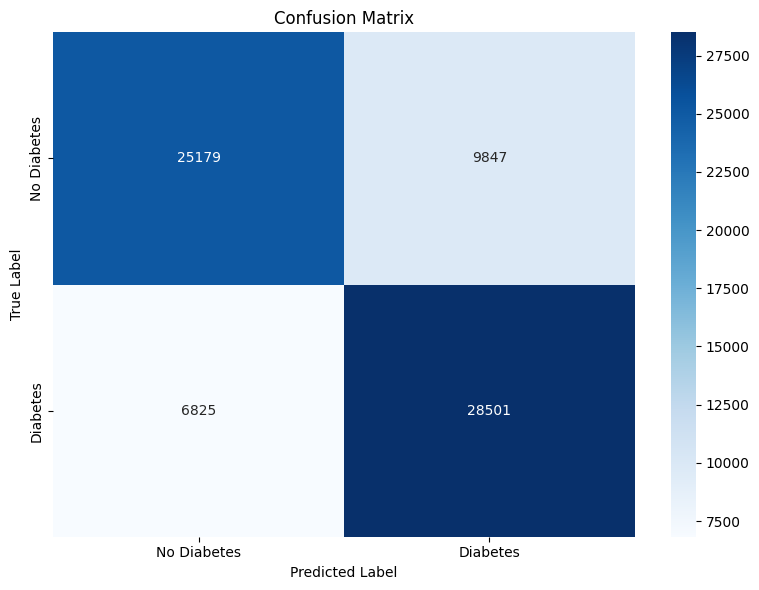

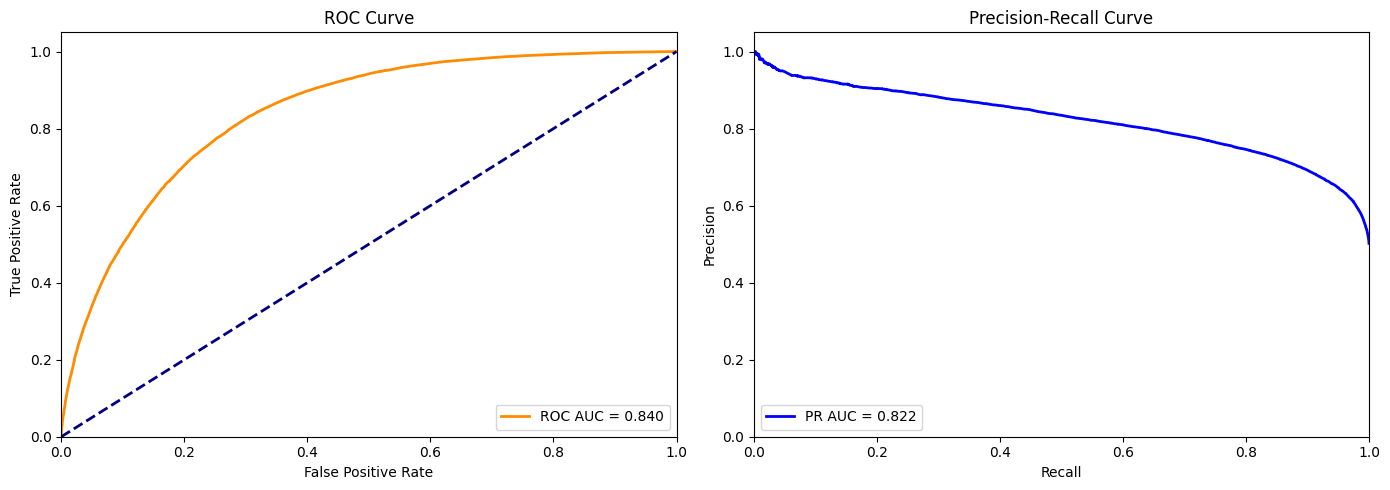

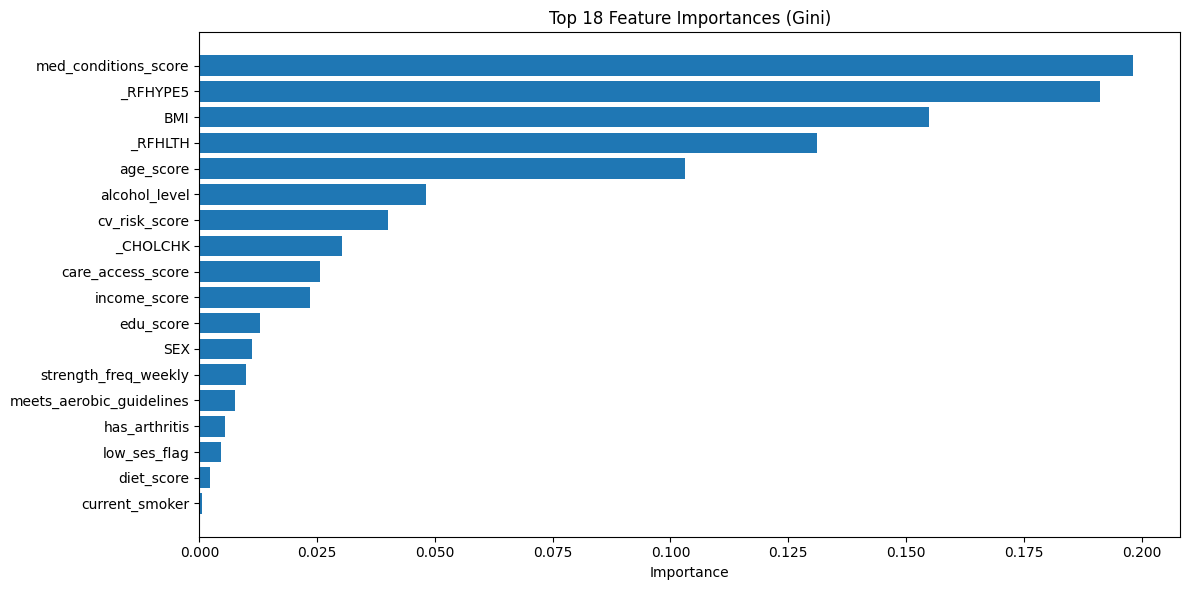

Exporting a single decision tree for visualization...
Computing cross-validated predictions on training set...


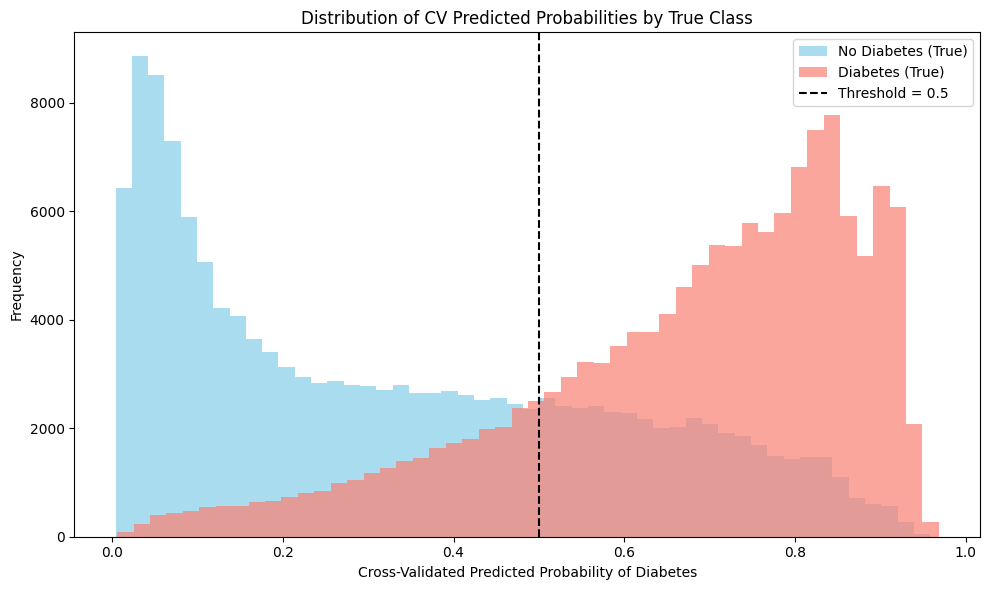

Cross-Validated Accuracy (Training Set): 0.7622

 EVALUATION COMPLETE
Results saved to: ..\results\evaluation_results


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, accuracy_score
)
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import shap
from sklearn.tree import export_graphviz
import graphviz

import matplotlib.image as mpimg
from sklearn.tree import export_graphviz



# Define and Create Paths

data_path = os.path.join("..", "data", "train-test")
models_path = os.path.join("..", "models")
results_path = os.path.join("..", "results", "evaluation_results")
os.makedirs(data_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True) 

# Load Preprocessed Data

print("Loading preprocessed data...")
train_df = pd.read_csv(os.path.join(data_path, "train_set.csv"))
test_df = pd.read_csv(os.path.join(data_path, "test_set.csv"))

X_train = train_df.drop(columns=['HasDiabetes'])
y_train = train_df['HasDiabetes']
X_test = test_df.drop(columns=['HasDiabetes'])
y_test = test_df['HasDiabetes']

# Load Trained Models

print("Loading trained models...")
final_model = joblib.load(os.path.join(models_path, "randomforest_diabetes_final.joblib"))
calibrated_model = joblib.load(os.path.join(models_path, "randomforest_diabetes_calibrated.joblib"))

# Ensure feature names are preserved
feature_names = X_test.columns.tolist()
X_test_df = X_test.copy()  

#  Generate Predictions (Calibrated Model)

y_pred_proba = calibrated_model.predict_proba(X_test)[:, 1]  # Prob of Diabetes (class 1)
y_pred = calibrated_model.predict(X_test)

# Classification Report

print("\n--- Classification Report (Calibrated Model) ---")
report = classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes'], output_dict=True)
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

# Save report as CSV
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(os.path.join(results_path, "classification_report.csv"))

# Confusion Matrix Plot

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# ROC & Precision-Recall Curves

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend(loc="lower right")

ax[1].plot(recall, precision, color='blue', lw=2, label=f'PR AUC = {pr_auc:.3f}')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig(os.path.join(results_path, 'roc_pr_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance (from base RF) - FIXED

importances = final_model.feature_importances_
n_features = len(importances)
indices = np.argsort(importances)[::-1]

# Plot top N features (or all if < 20)
top_n = min(20, n_features)

plt.figure(figsize=(12, max(6, top_n * 0.3)))  
plt.title(f"Top {top_n} Feature Importances (Gini)")
plt.barh(range(top_n), importances[indices[:top_n]], align="center")
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.gca().invert_yaxis()  
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save full importance (all features)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
importance_df.to_csv(os.path.join(results_path, 'feature_importance.csv'), index=False)


# ----------------------------
# 10. Visualize One Decision Tree from the Forest
# ----------------------------

print("Exporting a single decision tree for visualization...")

# Extract the first tree (index 0) from the forest
single_tree = final_model.estimators_[0]

# Export as DOT data
dot_data = export_graphviz(
    single_tree,
    out_file=None,
    feature_names=feature_names,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3  
)


# Cross-Validated Predictions (on TRAIN set)

print("Computing cross-validated predictions on training set...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv_proba = cross_val_predict(final_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
y_cv_pred = cross_val_predict(final_model, X_train, y_train, cv=cv, method='predict')

cv_results_df = pd.DataFrame({
    'Real': y_train,
    'CV_Predicted_Prob': y_cv_proba,
    'CV_Predicted_Class': y_cv_pred
})
cv_results_df.to_csv(os.path.join(results_path, 'cv_predictions.csv'), index=False)

# Plot CV probability distributions
plt.figure(figsize=(10, 6))
plt.hist(cv_results_df[cv_results_df['Real'] == 0]['CV_Predicted_Prob'], 
         bins=50, alpha=0.7, label='No Diabetes (True)', color='skyblue')
plt.hist(cv_results_df[cv_results_df['Real'] == 1]['CV_Predicted_Prob'], 
         bins=50, alpha=0.7, label='Diabetes (True)', color='salmon')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold = 0.5')
plt.xlabel('Cross-Validated Predicted Probability of Diabetes')
plt.ylabel('Frequency')
plt.title('Distribution of CV Predicted Probabilities by True Class')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'cv_probability_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

cv_acc = accuracy_score(y_train, y_cv_pred)
print(f"Cross-Validated Accuracy (Training Set): {cv_acc:.4f}")

# Final Summary

print("\n" + "="*60)
print(" EVALUATION COMPLETE")
print(f"Results saved to: {results_path}")
print("="*60)

 Tree visualization saved: ..\results\evaluation_results\rf_tree_0_depth4.png


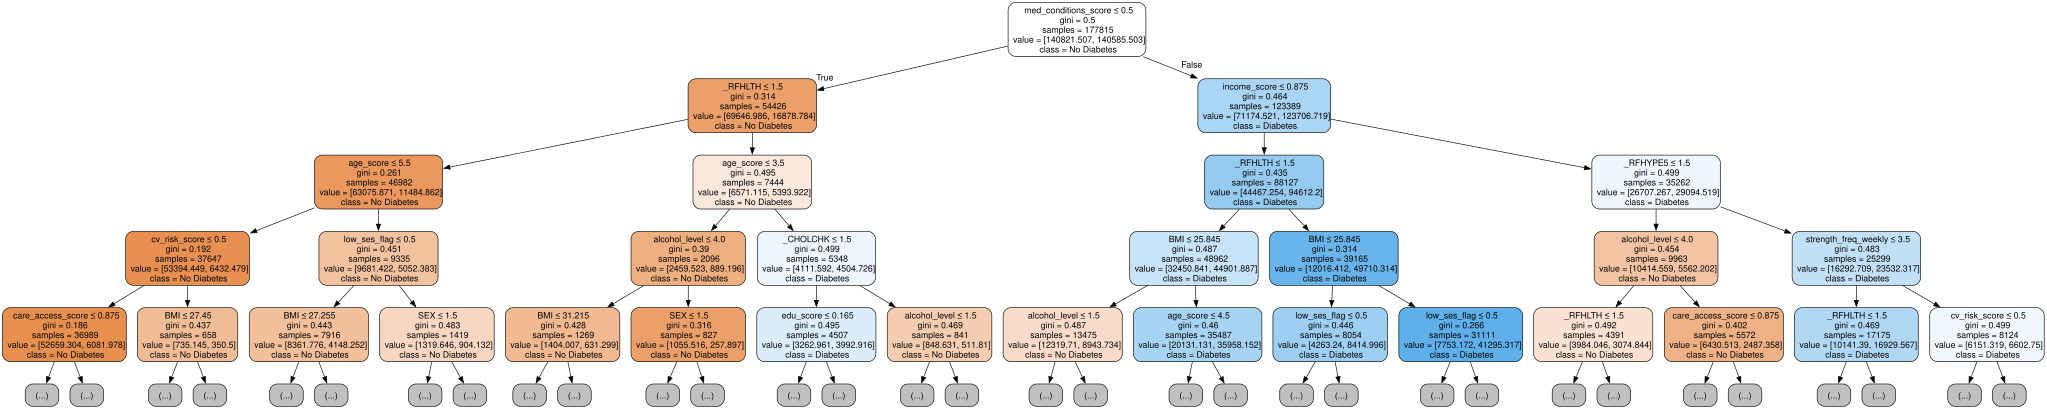

In [ ]:
# Visualize One Tree from Random Forest (Graphviz + Display)



# Pick one tree
tree_idx = 0
single_tree = final_model.estimators_[tree_idx]
max_depth_to_show = 4  # Keep it readable (3-4 is ideal)

# Export tree to DOT
dot_data = export_graphviz(
    single_tree,
    out_file=None,
    feature_names=X_test.columns.tolist(),
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=max_depth_to_show
)

# Define output path
output_path = os.path.join(results_path, f"rf_tree_{tree_idx}_depth{max_depth_to_show}")

# Render to PNG
graph = graphviz.Source(dot_data)
graph.render(output_path, format='png', cleanup=True)  # Saves as .png

print(f" Tree visualization saved: {output_path}.png")

#  DISPLAY THE TREE IN OUTPUT

try:
    from IPython.display import display
    display(graph)
except Exception as e:

    try:
        img_path = output_path + ".png"
        img = mpimg.imread(img_path)
        plt.figure(figsize=(16, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Decision Tree #{tree_idx} from Random Forest (Max Depth = {max_depth_to_show})", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as ex:
        print(f" Could not display image: {ex}")
        print("But the PNG file was saved successfully.")